# MOSAIC Demonstration: 2D Chemical Short-Range Order in PMN-PT

## Filter-Based Approach Linking Diffuse Scattering Features to Site-Resolved Real-Space Fields

This notebook demonstrates the MOSAIC **chemical ordering** workflow using a **2D slice from
a 3D PMN-PT supercell**. In PMN-PT (Pb(Mg$_{1/3}$Nb$_{2/3}$)$_{1-x}$Ti$_x$O$_3$), the B-site
sublattice hosts three cation species — Mg, Nb, and Ti — whose spatial arrangement gives rise
to rocksalt-type chemical short-range order (CSRO).  The addition of Ti partially disrupts the
Mg/Nb rocksalt ordering, making PMN-PT an ideal test case for comparing ordering strength
against the end-member PMN composition.

**Workflow overview:**
1. Load an atomistic configuration (`.f2d` structure file) with site-resolved atomic-number coefficients
2. Compute scattering amplitude via type-3 NUFFT using coefficient-weighted contributions
3. Visualise the diffuse scattering intensity with a circular mask overlay at superstructure positions
4. Apply a circular reciprocal-space mask around half-integer reflections and invert to obtain site-resolved chemical ordering fields
5. Compare unfiltered vs. filtered ordering maps

Unlike the displacement mode (which uses an M-decoder to extract vector displacement fields),
the **chemical mode** (Average-Position estimator) directly yields a scalar site-resolved
intensity whose sign and magnitude encode the local rocksalt order parameter.

In [1]:
import sys, os, json, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Ensure MOSAIC project root is on the path
MOSAIC_ROOT = Path(os.path.abspath("")).parent  # adjust if needed
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

# Enable saving of intermediate scattering interval artifacts (.npz files)
os.environ["MOSAIC_SAVE_SCATTERING_INTERVAL_ARTIFACTS"] = "1"

# Force CPU NUFFT if no GPU is available (uncomment if needed)
# os.environ["MOSAIC_NUFFT_CPU_ONLY"] = "1"

# Configuration
EXAMPLE_DIR = Path("config_2D/chemical_ordering")
STRUCTURE_FILE = "sample_2d_chem_PMNPT_2Dcol10.f2d"

print(f"MOSAIC root : {MOSAIC_ROOT.name}")
print(f"Example dir : {EXAMPLE_DIR}")
print(f"Structure   : {STRUCTURE_FILE}")

MOSAIC root : MOSAIC
Example dir : config_2D/chemical_ordering
Structure   : sample_2d_chem_PMNPT_2Dcol10.f2d


## 1. Inspect the Structure File

The `.f2d` file contains a 2D slice from a 3D PMN-PT supercell (40 x 40 unit cells, 1600 atoms)
with **atomic-number coefficients** for each B-site. Unlike the displacement case (where atoms
are displaced from average positions), here the actual and average positions are identical
(`X = Xav`, `Y = Yav`) and the relevant physical quantity is the **coefficient** column,
which encodes the B-site species via its atomic number (Z).

Three elements appear on the B-site sublattice:
- **Nb** (Z = 41) — niobium
- **Ti** (Z = 22) — titanium
- **Mg** (Z = 12) — magnesium

The spatial pattern of these species encodes the rocksalt-type chemical short-range order,
partially disrupted by Ti substitution.

In [2]:
struct_path = EXAMPLE_DIR / STRUCTURE_FILE

with open(struct_path) as f:
    lines = f.readlines()

# Parse header
import re
sc_match = re.search(r"Supercell dimensions:\s+(\d+)\s+(\d+)", lines[0])
supercell_dims = [int(sc_match.group(1)), int(sc_match.group(2))]

cell_match = re.findall(r"[\d.]+", lines[1])
cell_params = [float(x) for x in cell_match]

n_atoms = len(lines) - 3  # skip header, cell, column-header lines

# Parse elements and coefficients (data lines are space-delimited)
elements, coeffs = [], []
for line in lines[3:]:
    parts = line.strip().split()
    if len(parts) >= 7:
        elements.append(parts[0])
        coeffs.append(float(parts[6]))
elements = np.array(elements)
coeffs = np.array(coeffs)

print(f"Supercell dimensions : {supercell_dims}")
print(f"Cell (Ang/deg)       : {cell_params}")
print(f"Number of atoms      : {n_atoms}")
print(f"\nElement types        : {np.unique(elements)}")
print(f"Coefficient (Z) vals : {np.unique(coeffs)}")
print(f"Nb sites (Z=41)      : {np.sum(coeffs == 41)}")
print(f"Ti sites (Z=22)      : {np.sum(coeffs == 22)}")
print(f"Mg sites (Z=12)      : {np.sum(coeffs == 12)}")
print(f"\nFirst 5 atom lines:")
for line in lines[3:8]:
    print(f"  {line.strip()}")

Supercell dimensions : [40, 40]
Cell (Ang/deg)       : [162.08548, 162.08548, 90.0]
Number of atoms      : 1600

Element types        : ['El1']
Coefficient (Z) vals : [12. 22. 41.]
Nb sites (Z=41)      : 732
Ti sites (Z=22)      : 486
Mg sites (Z=12)      : 382

First 5 atom lines:
  El1 0.0125 0.0125 0.0125 0.0125 1 41
  El1 0.0125 0.0375 0.0125 0.0375 1 41
  El1 0.0125 0.0625 0.0125 0.0625 1 41
  El1 0.0125 0.0875 0.0125 0.0875 1 41
  El1 0.0125 0.1125 0.0125 0.1125 1 41


## 2. Run MOSAIC: Unfiltered (All Reciprocal Space)

First we run MOSAIC in **chemical mode** with **no mask** (pass-all equation) to compute the
coefficient-weighted scattering amplitude and extract unfiltered site intensities.

Key differences from displacement mode:
- `mode: "chemical"` — uses the Average-Position estimator
- `coefficients.source: "config"` — reads occupancy coefficients from the `.f2d` file
- `chemical_filtered_ordering: true` — enables coefficient-based NUFFT
- `coefficients.center_by: "global"` — subtracts the global mean coefficient before NUFFT
- No M-decoder is needed (no `decoder` section in config)
- Coarser real-space grid (`step_in_angstrom: [0.8125, 0.8125]`) since we extract a scalar, not a displacement vector

In [3]:
# --- Write config for UNMASKED run ---
UNMASKED_CONFIG = {
    "schema_version": 2,
    "paths": {
        "config_root": str(EXAMPLE_DIR.resolve()),
        "structure_file": STRUCTURE_FILE,
        "output_directory": str((EXAMPLE_DIR / "output_demo_pmnpt_all").resolve()),
    },
    "structure": {
        "dimension": 2,
        "coefficients": {"source": "config"},
    },
    "reciprocal_space": {
        "intervals": [{"limit": [40.0, 40.0], "subvolume_step": [5.0, 5.0]}],
        "mask": {"equation": "h**2 + k**2 + 1 >= 0"},
    },
    "processing": {
        "mode": "chemical",
        "method": "from_average",
        "num_chunks": 1,
        "fresh_start": True,
        "run_postprocessing": True,
        "chemical_filtered_ordering": True,
        "coefficients": {"center_by": "global", "use": True},
        "points": [
            {
                "selector": {"element": "El1", "reference_number": 1},
                "window": {
                    "dist_from_atom_center": [0.8, 0.8],
                    "step_in_angstrom": [0.8125, 0.8125],
                },
            }
        ],
    },
    "runtime": {
        "progress": {"force": True, "task_logs": True},
        "dask": {
            "backend": "local",
            "max_workers": 4,
            "threads_per_worker": 1,
            "processes": True,
            "worker_wait_timeout": "30s",
        },
        "scattering_weights": {"kind": "ones", "calculator": "default"},
    },
}

# Write to file
unmasked_input_path = EXAMPLE_DIR / "input_parameters_demo_pmnpt_all.json"
with open(unmasked_input_path, "w") as f:
    json.dump(UNMASKED_CONFIG, f, indent=2)

# Write run_parameters pointing to the input config
unmasked_run_path = EXAMPLE_DIR / "run_parameters_demo_pmnpt_all.json"
with open(unmasked_run_path, "w") as f:
    json.dump({"input_parameters_path": str(unmasked_input_path.resolve())}, f, indent=2)

print(f"Unmasked config written to: {unmasked_input_path}")
print(f"Run parameters written to:  {unmasked_run_path}")

Unmasked config written to: config_2D/chemical_ordering/input_parameters_demo_pmnpt_all.json
Run parameters written to:  config_2D/chemical_ordering/run_parameters_demo_pmnpt_all.json


In [4]:
from core.entrypoints.main import main as mosaic_main

# Run MOSAIC (unmasked) -- chemical mode, coefficient-weighted scattering
print("=" * 60)
print("Running MOSAIC -- UNMASKED (all reciprocal space, chemical mode)")
print("=" * 60)
mosaic_main(str(unmasked_run_path.resolve()))

Running MOSAIC -- UNMASKED (all reciprocal space, chemical mode)
2026-03-17 19:22:48,647 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-17 19:22:48,648 - [INFO] - app - (main.py:57) - Using input parameters: config_2D/chemical_ordering/input_parameters_demo_pmnpt_all.json
2026-03-17 19:22:48,648 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_2D/chemical_ordering
2026-03-17 19:22:48,648 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True
2026-03-17 19:22:50,351 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-17 19:22:50,351 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-17 19:22:50,352 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) -

Precompute intervals: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:13<00:00, 19.30intervals/s]

2026-03-17 19:23:11,054 - [INFO] - core.scattering.execution - (execution.py:492) - Stage-1 complete: 256 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-17 19:23:11,059 - [INFO] - core.scattering.execution - (execution.py:758) - Completed scattering interval precompute stage


2026-03-17 19:23:11,139 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_pmnpt_all/processed_point_data
2026-03-17 19:23:11,202 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:23:11,208 - [INFO] - core.residual_field.execution - (execution.py:1101) - Residual-field partition plan | chunk=0 | dim=2 | points=1600 | rifft_points=1600 | est_bytes=89600 | target_bytes=268435456 | hysteresis_band=214748365-322122547 | partitions=4 | partition_rifft_points=(400, 400, 400, 400) | imbalance=1.000 | reason=worker-capacity-floor
2026-03-17 19:23:11,381 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:23:11,386 - [INF

Residual-field:   0%|                                                                                                                                                               | 0/256 [00:00<?, ?batch/s]

...

Residual-field:  98%|█████████████████████████████████████████████████████████████████████████████████████████▌ | 252/256 [00:16<00:00, 15.14batch/s, chunk=0 | running=0 | elapsed=17s | eta=0s | rate=15.1/s]

2026-03-17 19:23:28,029 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 256/256 (100%) | running=4 | chunk=0 | intervals=253,254,255,256


Residual-field: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:17<00:00, 15.05batch/s, chunk=0 | running=0 | elapsed=17s]

2026-03-17 19:23:28,471 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:23:28,472 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:23:28,472 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:23:28,473 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:23:28,473 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=4 | 

2026-03-17 19:23:28,728 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_pmnpt_all/processed_point_data/point_data_chunk_0_shapeNd.hdf5
2026-03-17 19:23:37,438 - [INFO] - core.residual_field.execution - (execution.py:1580) - Residual-field finished – 256 tasks submitted
2026-03-17 19:23:38,873 - [INFO] - core.runtime.dask_helpers - (dask_helpers.py:514) - Dask client closed.


## 3. Diffuse Scattering Intensity with Circular Mask Overlay

The scattering amplitude in chemical mode is computed using **coefficient-weighted** contributions:

$$A_{\mathrm{coeff}}(\mathbf{Q}) = \sum_s \Delta c_s \, e^{i\mathbf{Q}\cdot\bar{\mathbf{r}}_s}$$

where $\Delta c_s = c_s - \langle c \rangle$ is the mean-centred atomic-number coefficient at site $s$,
and $\bar{\mathbf{r}}_s$ is the average position. Because the NUFFT uses only average positions
(no displacements), the resulting amplitude isolates chemical ordering from displacement effects.

The **circular mask** selects small discs of radius $r = 0.198$ r.l.u. centred at every
half-integer position $(h + \tfrac{1}{2}, k + \tfrac{1}{2})$. These are the superstructure
reflections associated with rocksalt-type B-site ordering in perovskites.

In [5]:
# --- Helper functions (shared with displacement notebook) ---

def load_interval_data(output_dir):
    """Load q_grid, q_amp, q_amp_av from all interval .npz files."""
    interval_dir = Path(output_dir) / "processed_point_data" / "precomputed_intervals"
    npz_files = sorted(interval_dir.glob("interval_*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No interval_*.npz files found in {interval_dir}")

    all_q_grid, all_q_amp, all_q_amp_av = [], [], []
    for npz_path in npz_files:
        data = np.load(npz_path)
        all_q_grid.append(data["q_grid"])
        all_q_amp.append(data["q_amp"])
        all_q_amp_av.append(data["q_amp_av"])
        data.close()

    return (np.concatenate(all_q_grid, axis=0),
            np.concatenate(all_q_amp, axis=0),
            np.concatenate(all_q_amp_av, axis=0))


def unique_sorted_tol(a, tol=1e-10):
    """Unique sorted values, merging near-equals."""
    s = np.sort(np.asarray(a, dtype=float))
    if s.size == 0:
        return s
    out = [s[0]]
    for v in s[1:]:
        if abs(v - out[-1]) > tol:
            out.append(v)
    return np.array(out)


def nearest_index(vec, vals):
    """For each vals[i], return index of nearest vec[j]."""
    vec, vals = np.asarray(vec, float), np.asarray(vals, float)
    j = np.searchsorted(vec, vals)
    j0 = np.clip(j - 1, 0, vec.size - 1)
    j1 = np.clip(j, 0, vec.size - 1)
    d0, d1 = np.abs(vals - vec[j0]), np.abs(vals - vec[j1])
    return np.where(d1 < d0, j1, j0)


def build_intensity_grid(q_grid, intensity, cell_param, supercell_dim):
    """Convert q_grid (internal units) to hkl and reshape into a 2D grid."""
    Q_hkl = cell_param * q_grid / (supercell_dim * 2 * np.pi)
    h, k = Q_hkl[:, 0], Q_hkl[:, 1]

    hv = unique_sorted_tol(h)
    kv = unique_sorted_tol(k)
    Nh, Nk = hv.size, kv.size

    ih = nearest_index(hv, h)
    ik = nearest_index(kv, k)

    I2 = np.full((Nk, Nh), np.nan)
    I2[ik, ih] = intensity
    return hv, kv, I2


def make_circle_mask_grid(hv, kv, radius=0.198):
    """Build a boolean mask selecting circles of given radius at every half-integer position."""
    hh, kk = np.meshgrid(hv, kv)  # shape (Nk, Nh)
    # Distance from nearest half-integer point
    dh = np.mod(hh, 1.0) - 0.5
    dk = np.mod(kk, 1.0) - 0.5
    dist_sq = dh**2 + dk**2
    return dist_sq <= radius**2


print("Helpers loaded.")

Helpers loaded.


In [6]:
# --- Load unfiltered amplitudes and compute intensity ---
CELL_PARAM = cell_params[0]
SC_DIM = supercell_dims[0]

unmasked_output = EXAMPLE_DIR / "output_demo_pmnpt_all"
q_grid, q_amp, q_amp_av = load_interval_data(unmasked_output)

# Total intensity: |A_coeff(Q)|^2
intensity_total = (q_amp * np.conj(q_amp)).real

# Diffuse intensity: |A_coeff(Q) - <A_coeff(Q)>|^2
intensity_diffuse = ((q_amp - q_amp_av) * np.conj(q_amp - q_amp_av)).real

# Build 2D grids
hv, kv, I_total_2d = build_intensity_grid(q_grid, intensity_total, CELL_PARAM, SC_DIM)
_, _, I_diffuse_2d = build_intensity_grid(q_grid, intensity_diffuse, CELL_PARAM, SC_DIM)

print(f"Q-grid shape   : {q_grid.shape}")
print(f"Intensity grid : ({len(kv)}, {len(hv)})")
print(f"h range        : [{hv.min():.1f}, {hv.max():.1f}]")
print(f"k range        : [{kv.min():.1f}, {kv.max():.1f}]")

Q-grid shape   : (10246401, 2)
Intensity grid : (3201, 3201)
h range        : [-40.0, 40.0]
k range        : [-40.0, 40.0]


In [7]:
# --- Generate the circular mask on the same hkl grid ---
circle_mask = make_circle_mask_grid(hv, kv, radius=0.198)
n_masked = circle_mask.sum()
n_total = circle_mask.size
print(f"Mask coverage: {n_masked}/{n_total} points ({100*n_masked/n_total:.1f}%)")

Mask coverage: 1235200/10246401 points (12.1%)


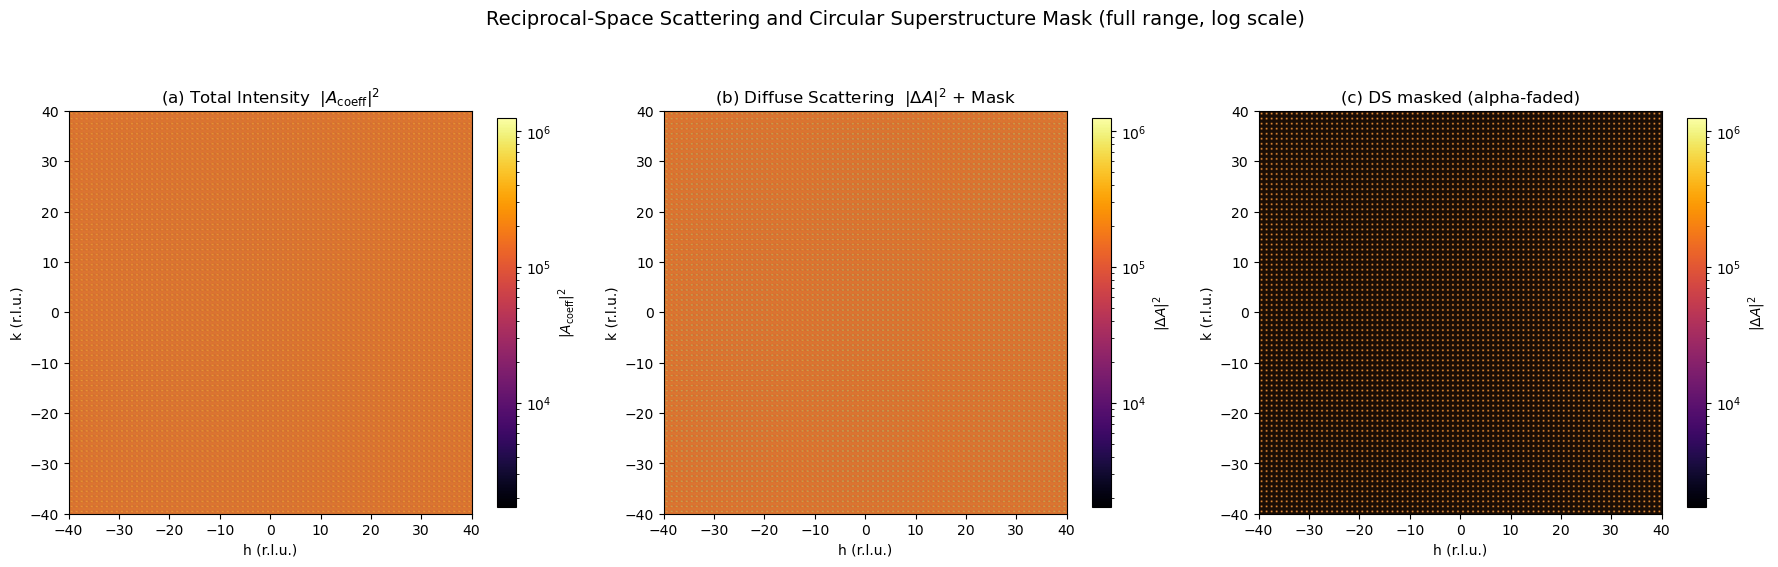

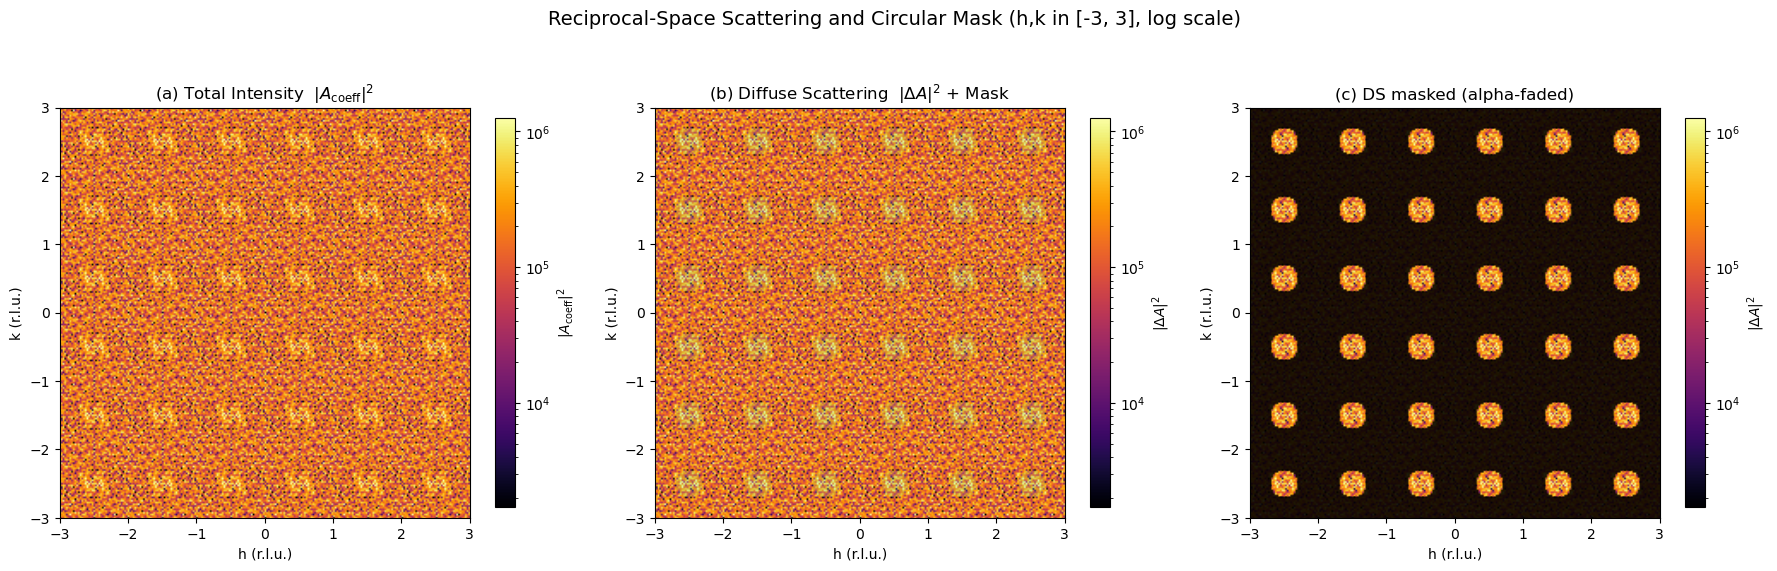

In [8]:
# --- Plot: Scattering + Semi-Transparent Circular Mask Overlay (log scale) ---
from matplotlib.colors import LogNorm

# Clip zeros for log scale
I_total_log = np.where(I_total_2d > 0, I_total_2d, np.nan)
I_diffuse_log = np.where(I_diffuse_2d > 0, I_diffuse_2d, np.nan)

# Percentile-based colour limits
vmin_tot = np.nanpercentile(I_total_log, 1)
vmax_tot = np.nanpercentile(I_total_log, 99.5)
vmin_ds = np.nanpercentile(I_diffuse_log, 1)
vmax_ds = np.nanpercentile(I_diffuse_log, 99.5)

extent = [hv.min(), hv.max(), kv.min(), kv.max()]

# --- Full range ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Total scattering intensity
ax = axes[0]
im0 = ax.imshow(I_total_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
fig.colorbar(im0, ax=ax, shrink=0.8, label="$|A_{\\mathrm{coeff}}|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(a) Total Intensity  $|A_{\\mathrm{coeff}}|^2$")

# (b) Diffuse scattering + mask overlay
ax = axes[1]
im1 = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))

# Overlay mask
mask_rgba = np.zeros((*circle_mask.shape, 4))
mask_rgba[circle_mask, :] = [0.0, 0.9, 1.0, 0.10]
ax.imshow(mask_rgba, origin="lower", extent=extent, aspect="equal", interpolation="nearest")

fig.colorbar(im1, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(b) Diffuse Scattering  $|\\Delta A|^2$ + Mask")

# (c) Diffuse intensity with alpha modulation
ax = axes[2]
im2 = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                aspect="equal", interpolation="bilinear",
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
alpha_grid = np.where(circle_mask, 1.0, 0.12)
im2.set_alpha(alpha_grid)
fig.colorbar(im2, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(c) DS masked (alpha-faded)")
ax.set_facecolor("black")

fig.suptitle("Reciprocal-Space Scattering and Circular Superstructure Mask (full range, log scale)",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# --- Zoomed view: hkl from -3 to 3 ---
HKL_LIM = 3
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes2[0]
im = ax.imshow(I_total_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(a) Total Intensity  $|A_{\\mathrm{coeff}}|^2$")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|A_{\\mathrm{coeff}}|^2$")

ax = axes2[1]
im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
ax.imshow(mask_rgba, origin="lower", extent=extent, aspect="equal", interpolation="nearest")
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(b) Diffuse Scattering  $|\\Delta A|^2$ + Mask")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")

ax = axes2[2]
im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
               aspect="equal", interpolation="bilinear",
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
im.set_alpha(alpha_grid)
ax.set_facecolor("black")
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel("h (r.l.u.)")
ax.set_ylabel("k (r.l.u.)")
ax.set_title("(c) DS masked (alpha-faded)")
fig2.colorbar(im, ax=ax, shrink=0.8, label="$|\\Delta A|^2$")

fig2.suptitle(
    f"Reciprocal-Space Scattering and Circular Mask (h,k in [-{HKL_LIM}, {HKL_LIM}], log scale)",
    fontsize=14, y=1.02,
)
fig2.tight_layout()
plt.show()

## 4. Zoomed Views: Mask around Superstructure Reflections

The circular mask targets the half-integer superstructure positions where chemical
short-range order produces diffuse intensity blobs. Here we zoom in on a few key
positions to show the mask geometry.

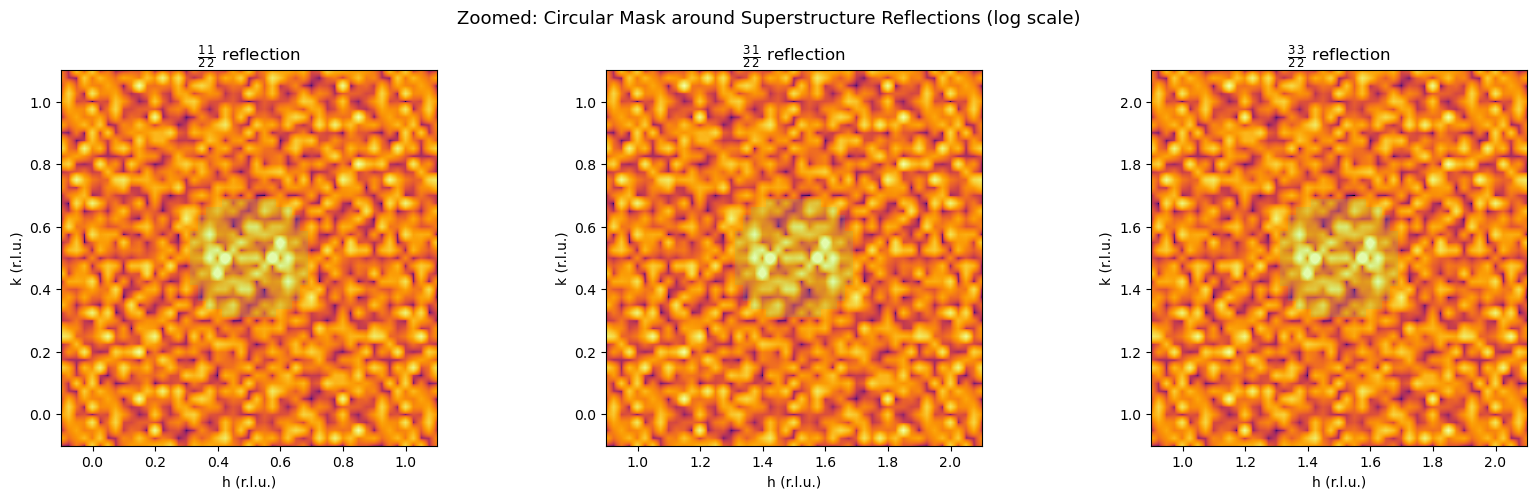

In [9]:
# --- Zoomed insets around specific superstructure reflections ---

zooms = [
    {"center": (0.5, 0.5), "half": 0.6, "label": r"$\frac{1}{2}\frac{1}{2}$ reflection"},
    {"center": (1.5, 0.5), "half": 0.6, "label": r"$\frac{3}{2}\frac{1}{2}$ reflection"},
    {"center": (1.5, 1.5), "half": 0.6, "label": r"$\frac{3}{2}\frac{3}{2}$ reflection"},
]

fig, axes = plt.subplots(1, len(zooms), figsize=(5.5 * len(zooms), 5))
if len(zooms) == 1:
    axes = [axes]

for ax, z in zip(axes, zooms):
    cx, cy = z["center"]
    hw = z["half"]

    im = ax.imshow(I_diffuse_log, origin="lower", extent=extent, cmap="inferno",
                   aspect="equal", interpolation="bilinear",
                   norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))

    # Mask overlay
    mask_rgba_z = np.zeros((*circle_mask.shape, 4))
    mask_rgba_z[circle_mask, :] = [0.0, 0.9, 1.0, 0.10]
    ax.imshow(mask_rgba_z, origin="lower", extent=extent, aspect="equal",
              interpolation="nearest")

    ax.set_xlim(cx - hw, cx + hw)
    ax.set_ylim(cy - hw, cy + hw)
    ax.set_xlabel("h (r.l.u.)")
    ax.set_ylabel("k (r.l.u.)")
    ax.set_title(z["label"])

fig.suptitle("Zoomed: Circular Mask around Superstructure Reflections (log scale)", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Run MOSAIC: Masked (Superstructure Reflections Only)

Now we apply the circular mask to select only the half-integer superstructure reflections
and invert via the chemical-mode estimator to obtain site-resolved ordering fields
associated with the rocksalt-type CSRO.

The **mask equation** selects circles of radius 0.198 r.l.u. centred at every
half-integer position: $(\mathrm{Mod}(h,1) - 0.5)^2 + (\mathrm{Mod}(k,1) - 0.5)^2 \leq 0.198^2$

The **complementary mask** selects everything except these circles.

In [10]:
# --- Circular mask equation (selects superstructure reflections) ---
CIRCLE_MASK_EQ = (
    "(((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) <= (0.198**2.0))"
)

# --- Complementary mask (everything except superstructure reflections) ---
REST_MASK_EQ = (
    "(((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) > (0.198**2.0))"
)


def write_chem_config(tag, mask_equation):
    """Write a MOSAIC chemical-mode config for a demo run."""
    output_dir_name = f"output_demo_pmnpt_{tag}"

    config = {
        "schema_version": 2,
        "paths": {
            "config_root": str(EXAMPLE_DIR.resolve()),
            "structure_file": STRUCTURE_FILE,
            "output_directory": str((EXAMPLE_DIR / output_dir_name).resolve()),
        },
        "structure": {
            "dimension": 2,
            "coefficients": {"source": "config"},
        },
        "reciprocal_space": {
            "intervals": [{"limit": [40.0, 40.0], "subvolume_step": [5.0, 5.0]}],
            "mask": {"equation": mask_equation},
        },
        "processing": {
            "mode": "chemical",
            "method": "from_average",
            "num_chunks": 1,
            "fresh_start": True,
            "run_postprocessing": True,
            "chemical_filtered_ordering": True,
            "coefficients": {"center_by": "global", "use": True},
            "points": [
                {
                    "selector": {"element": "El1", "reference_number": 1},
                    "window": {
                        "dist_from_atom_center": [0.8, 0.8],
                        "step_in_angstrom": [0.8125, 0.8125],
                    },
                }
            ],
        },
        "runtime": {
            "progress": {"force": True, "task_logs": True},
            "dask": {
                "backend": "local",
                "max_workers": 4,
                "threads_per_worker": 1,
                "processes": True,
                "worker_wait_timeout": "30s",
            },
            "scattering_weights": {"kind": "ones", "calculator": "default"},
        },
    }

    input_path = EXAMPLE_DIR / f"input_parameters_demo_pmnpt_{tag}.json"
    run_path = EXAMPLE_DIR / f"run_parameters_demo_pmnpt_{tag}.json"

    with open(input_path, "w") as f:
        json.dump(config, f, indent=2)
    with open(run_path, "w") as f:
        json.dump({"input_parameters_path": str(input_path.resolve())}, f, indent=2)

    return run_path


masked_run_path = write_chem_config("masked", CIRCLE_MASK_EQ)
rest_run_path = write_chem_config("rest", REST_MASK_EQ)

print(f"Masked run config:        {masked_run_path}")
print(f"Complementary run config: {rest_run_path}")

Masked run config:        config_2D/chemical_ordering/run_parameters_demo_pmnpt_masked.json
Complementary run config: config_2D/chemical_ordering/run_parameters_demo_pmnpt_rest.json


In [11]:
# Reset Dask/asyncio state so a fresh client can be created
import asyncio
try:
    asyncio.get_event_loop().close()
except:
    pass
asyncio.set_event_loop(asyncio.new_event_loop())

import core.runtime.dask_client as _dc
_dc._CLIENT = None

# Run MOSAIC -- MASKED (superstructure reflections only)
print("=" * 60)
print("Running MOSAIC -- MASKED (superstructure reflections)")
print("=" * 60)
mosaic_main(str(masked_run_path.resolve()))

Running MOSAIC -- MASKED (superstructure reflections)
2026-03-17 19:24:04,108 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-17 19:24:04,109 - [INFO] - app - (main.py:57) - Using input parameters: config_2D/chemical_ordering/input_parameters_demo_pmnpt_masked.json
2026-03-17 19:24:04,109 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_2D/chemical_ordering
2026-03-17 19:24:04,109 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True
2026-03-17 19:24:05,587 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-17 19:24:05,588 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-17 19:24:05,589 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) - average

Precompute intervals: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:09<00:00, 26.24intervals/s]

2026-03-17 19:24:24,113 - [INFO] - core.scattering.execution - (execution.py:492) - Stage-1 complete: 256 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-17 19:24:24,118 - [INFO] - core.scattering.execution - (execution.py:758) - Completed scattering interval precompute stage


2026-03-17 19:24:24,186 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_pmnpt_masked/processed_point_data
2026-03-17 19:24:24,204 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:24:24,209 - [INFO] - core.residual_field.execution - (execution.py:1101) - Residual-field partition plan | chunk=0 | dim=2 | points=1600 | rifft_points=1600 | est_bytes=89600 | target_bytes=268435456 | hysteresis_band=214748365-322122547 | partitions=4 | partition_rifft_points=(400, 400, 400, 400) | imbalance=1.000 | reason=worker-capacity-floor
2026-03-17 19:24:24,370 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:24:24,374 - [

Residual-field:   0%|                                                                                                                                                               | 0/256 [00:00<?, ?batch/s]

...

Residual-field:  98%|█████████████████████████████████████████████████████████████████████████████████████████▌ | 252/256 [00:09<00:00, 25.57batch/s, chunk=0 | running=0 | elapsed=10s | eta=0s | rate=25.6/s]

2026-03-17 19:24:34,228 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 256/256 (100%) | running=4 | chunk=0 | intervals=253,254,255,256


Residual-field: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:10<00:00, 25.35batch/s, chunk=0 | running=0 | elapsed=10s]

2026-03-17 19:24:34,531 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:24:34,532 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:24:34,533 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:24:34,533 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:24:34,534 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=4 | 

2026-03-17 19:24:34,913 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_pmnpt_masked/processed_point_data/point_data_chunk_0_shapeNd.hdf5
2026-03-17 19:24:42,854 - [INFO] - core.residual_field.execution - (execution.py:1580) - Residual-field finished – 256 tasks submitted
2026-03-17 19:24:44,506 - [INFO] - core.runtime.dask_helpers - (dask_helpers.py:514) - Dask client closed.


In [12]:
# Reset Dask/asyncio state again
try:
    asyncio.get_event_loop().close()
except:
    pass
asyncio.set_event_loop(asyncio.new_event_loop())
_dc._CLIENT = None

# Run MOSAIC -- COMPLEMENTARY (everything except superstructure reflections)
print("=" * 60)
print("Running MOSAIC -- COMPLEMENTARY (rest of reciprocal space)")
print("=" * 60)
mosaic_main(str(rest_run_path.resolve()))

Running MOSAIC -- COMPLEMENTARY (rest of reciprocal space)
2026-03-17 19:24:44,647 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-17 19:24:44,648 - [INFO] - app - (main.py:57) - Using input parameters: config_2D/chemical_ordering/input_parameters_demo_pmnpt_rest.json
2026-03-17 19:24:44,648 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_2D/chemical_ordering
2026-03-17 19:24:44,649 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=4 threads_per_worker=1 processes=True
2026-03-17 19:24:46,348 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-17 19:24:46,348 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-17 19:24:46,349 - [WARNING] - core.patch_centers.from_average - (from_average.py:35) - aver

Precompute intervals: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:12<00:00, 20.13intervals/s]

2026-03-17 19:25:18,025 - [INFO] - core.scattering.execution - (execution.py:492) - Stage-1 complete: 256 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-17 19:25:18,033 - [INFO] - core.scattering.execution - (execution.py:758) - Completed scattering interval precompute stage
2026-03-17 19:25:18,116 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_pmnpt_rest/processed_point_data
2026-03-17 19:25:18,133 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:25:18,139 - [INFO] - core.residual_field.execution - (execution.py:1101) - Residual-field partition plan | chunk=0 | dim=2 | points=1600 | rifft_points=1600 | est_bytes=89600 | target_bytes=268435

2026-03-17 19:25:18,400 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=4 | workers=4 | nufft_slots=4
2026-03-17 19:25:18,405 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=256 | chunks=1 | batch_size=4 | max_inflight=4 | cleanup=off


Residual-field:   0%|                                                                                                                                                               | 0/256 [00:00<?, ?batch/s]

...

Residual-field:  98%|█████████████████████████████████████████████████████████████████████████████████████████▌ | 252/256 [00:16<00:00, 15.51batch/s, chunk=0 | running=0 | elapsed=16s | eta=0s | rate=15.5/s]

2026-03-17 19:25:34,649 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 256/256 (100%) | running=4 | chunk=0 | intervals=253,254,255,256


Residual-field: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:16<00:00, 15.48batch/s, chunk=0 | running=0 | elapsed=17s]

2026-03-17 19:25:35,002 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:25:35,003 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:25:35,004 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:25:35,004 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 3) | writes=4 | bytes=28590 | wall=0.000s
2026-03-17 19:25:35,005 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=4 | 

2026-03-17 19:25:35,060 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_pmnpt_rest/processed_point_data/point_data_chunk_0_shapeNd.hdf5
2026-03-17 19:25:42,022 - [INFO] - core.residual_field.execution - (execution.py:1580) - Residual-field finished – 256 tasks submitted
2026-03-17 19:25:43,472 - [INFO] - core.runtime.dask_helpers - (dask_helpers.py:514) - Dask client closed.


## 6. Load and Compare Chemical Ordering Fields

We now load the decoded site-resolved intensities from all three MOSAIC runs:
- **Unfiltered**: all reciprocal space — the full coefficient-weighted field
- **Masked** (superstructure circles): chemical ordering associated with rocksalt-type CSRO
- **Complementary** (rest): signal from non-superstructure regions

The chemical-mode estimator extracts a complex scalar intensity at each atomic site.
The **real part** of the intensity acts as a local order parameter:
- Positive values indicate sites with one phase of the rocksalt order
- Negative values indicate the opposite phase
- Near-zero values correspond to disordered or anti-phase boundary regions

In [13]:
import csv


def load_site_contrast(output_dir, chunk_id=0):
    """Load site-resolved intensities from a chemical-mode MOSAIC output."""
    proc_dir = Path(output_dir) / "processed_point_data"

    for pattern in [
        f"chunk_{chunk_id}_site_contrast.csv",
        f"output_chunk_{chunk_id}_site_contrast.csv",
    ]:
        csv_path = proc_dir / pattern
        if csv_path.exists():
            break
    else:
        raise FileNotFoundError(
            f"No site_contrast CSV found in {proc_dir}. "
            f"Available files: {list(proc_dir.glob('*'))}"
        )

    ids, x_pos, y_pos, i_real, i_imag = [], [], [], [], []
    with open(csv_path) as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            ids.append(int(row["central_point_id"]))
            x_pos.append(float(row["x"]))
            y_pos.append(float(row["y"]))
            i_real.append(float(row["intensity_real"]))
            i_imag.append(float(row["intensity_imag"]))

    return (
        np.array(ids),
        np.array(x_pos),
        np.array(y_pos),
        np.array(i_real),
        np.array(i_imag),
    )


# Load site contrast from all three runs
ids_all, x_all, y_all, re_all, im_all = load_site_contrast(EXAMPLE_DIR / "output_demo_pmnpt_all")
ids_mask, x_mask, y_mask, re_mask, im_mask = load_site_contrast(EXAMPLE_DIR / "output_demo_pmnpt_masked")
ids_rest, x_rest, y_rest, re_rest, im_rest = load_site_contrast(EXAMPLE_DIR / "output_demo_pmnpt_rest")

print(f"Loaded {len(ids_all)} site intensities from each run")
print(f"  Unfiltered  RMS |I|: {np.sqrt(np.mean(re_all**2 + im_all**2)):.4f}")
print(f"  Masked      RMS |I|: {np.sqrt(np.mean(re_mask**2 + im_mask**2)):.4f}")
print(f"  Complement  RMS |I|: {np.sqrt(np.mean(re_rest**2 + im_rest**2)):.4f}")

Loaded 1600 site intensities from each run
  Unfiltered  RMS |I|: 12.2179
  Masked      RMS |I|: 5.2949
  Complement  RMS |I|: 11.0110


## 7. Chemical Ordering Maps

We visualise the site-resolved chemical ordering as heatmaps on the 2D lattice.
The colour encodes the **real part** of the site intensity (the order parameter):
- **(a)** Unfiltered field (all reciprocal space) — contains all contributions
- **(b)** Masked (superstructure reflections) — isolated rocksalt-type checkerboard ordering,
  with **anti-phase boundaries** (APBs) drawn as green contour lines
- **(c)** Complementary (rest) — signal outside superstructure positions

The rocksalt ordering produces a **checkerboard** pattern where neighbouring sites have
opposite sign. Anti-phase boundaries separate domains where this alternation is in phase
vs out of phase — i.e., where Cluster A and Cluster B have their sublattice assignments
swapped. To find APBs, we compute the **staggered order parameter** by multiplying
$\mathrm{Re}(I)$ by $(-1)^{i_x + i_y}$, which removes the checkerboard modulation
and yields a uniform field within each domain. The zero-crossings of this staggered
field are the anti-phase boundaries.

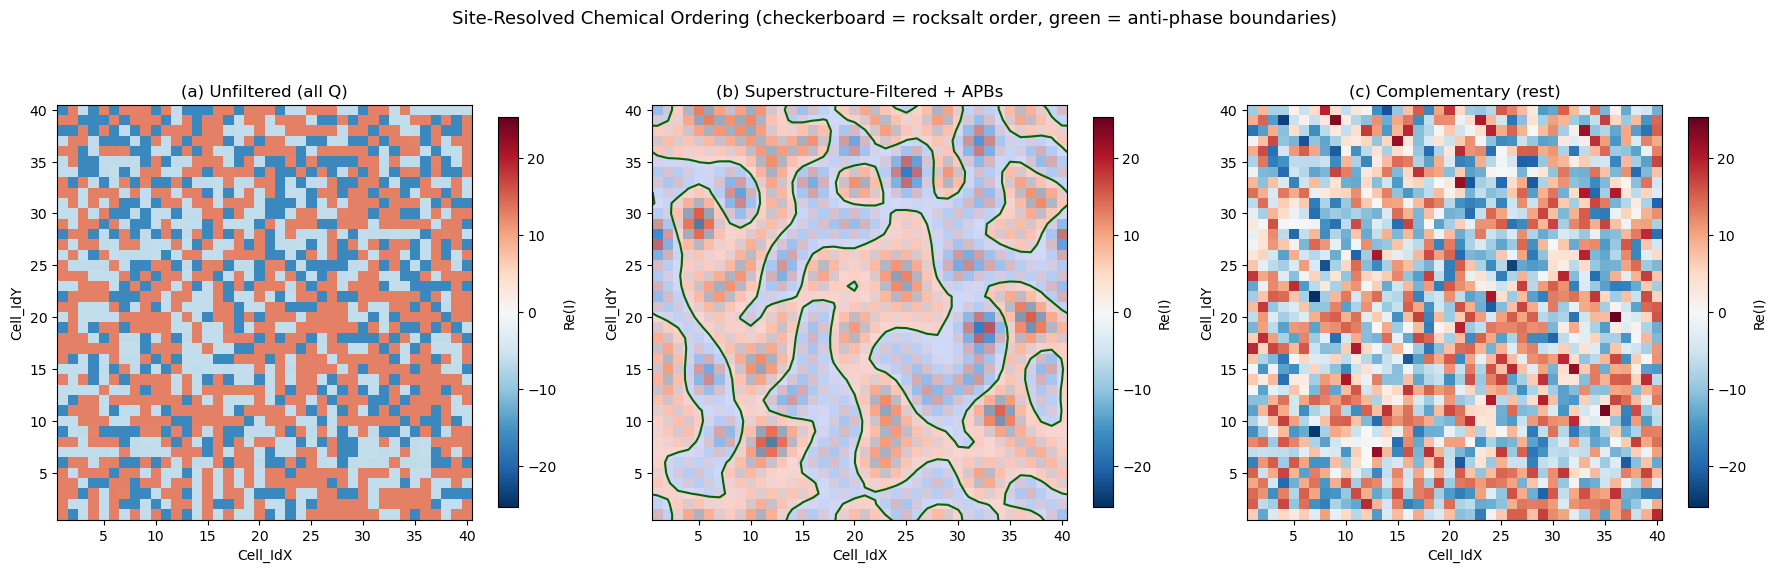

In [14]:
# --- Reshape site intensities onto the 2D lattice grid ---
n_side = SC_DIM  # 40

# Sort atoms by (x, y) to get correct grid ordering
order = np.lexsort((y_all, x_all))
re_all_2d = re_all[order].reshape(n_side, n_side)
re_mask_2d = re_mask[order].reshape(n_side, n_side)
re_rest_2d = re_rest[order].reshape(n_side, n_side)

# Cell indices for axes
cell_ids = np.arange(1, n_side + 1)

# --- Staggered order parameter: remove checkerboard modulation ---
# In rocksalt ordering, neighbours alternate sign. Multiplying by (-1)^(ix+iy)
# makes the field uniform within each coherently ordered domain.
ix, iy = np.meshgrid(np.arange(n_side), np.arange(n_side), indexing="ij")
stagger = (-1.0) ** (ix + iy)
re_mask_staggered = re_mask_2d * stagger

# Smooth with periodic (wrap) boundary conditions — the supercell is periodic
from scipy.ndimage import gaussian_filter
re_mask_smooth = gaussian_filter(re_mask_staggered, sigma=1.0, mode="wrap")

# --- Pad data by 1 cell on each side (periodic wrap) so contour lines ---
# --- connect correctly across opposite edges of the supercell.         ---
pad = 1
smooth_pad = np.pad(re_mask_smooth, pad, mode="wrap")
# Coordinates for padded grid: extend cell_ids by one cell in each direction
cell_ids_pad = np.arange(1 - pad, n_side + 1 + pad)

# --- Plot ---
datasets = [
    (re_all_2d, "(a) Unfiltered (all Q)"),
    (re_mask_2d, "(b) Superstructure-Filtered"),
    (re_rest_2d, "(c) Complementary (rest)"),
]

vmax_global = max(np.abs(re_all_2d).max(), np.abs(re_mask_2d).max(), np.abs(re_rest_2d).max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (values, title) in zip(axes, datasets):
    im = ax.pcolormesh(
        cell_ids, cell_ids, values.T,
        cmap="RdBu_r",
        vmin=-vmax_global, vmax=vmax_global,
        shading="nearest",
    )
    ax.set_aspect("equal")
    ax.set_xlabel("Cell_IdX")
    ax.set_ylabel("Cell_IdY")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Re(I)")

# --- Panel (b): semi-transparent domain highlights + APB contours ---
ax_b = axes[1]

# Blue fill for positive staggered domains (one rocksalt phase)
ax_b.contourf(
    cell_ids_pad, cell_ids_pad, smooth_pad.T,
    levels=[0, smooth_pad.max()],
    colors=["#0033FF"], alpha=0.15,
)
# Red fill for negative staggered domains (the other phase)
ax_b.contourf(
    cell_ids_pad, cell_ids_pad, smooth_pad.T,
    levels=[smooth_pad.min(), 0],
    colors=["#FF1A00"], alpha=0.15,
)

# Anti-phase boundary contour lines (on padded grid for edge continuity)
ax_b.contour(
    cell_ids_pad, cell_ids_pad, smooth_pad.T,
    levels=[0], colors="darkgreen", linewidths=1.5,
)
# Clip view to the original supercell extent
ax_b.set_xlim(cell_ids[0] - 0.5, cell_ids[-1] + 0.5)
ax_b.set_ylim(cell_ids[0] - 0.5, cell_ids[-1] + 0.5)
ax_b.set_title("(b) Superstructure-Filtered + APBs")

fig.suptitle(
    "Site-Resolved Chemical Ordering (checkerboard = rocksalt order, green = anti-phase boundaries)",
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.show()

## 8. Linearity Check: $I_{\text{mask}} + I_{\text{rest}} \approx I_{\text{all}}$

The MOSAIC framework is **strictly linear**: the site intensity reconstructed from the
full reciprocal space equals the sum of intensities reconstructed from any partition.
We verify this for both real and imaginary parts:

$$\Delta I = (I_{\text{mask}} + I_{\text{rest}}) - I_{\text{all}}$$

This should be negligible compared to the intensity magnitudes.

RMS |I_all|      : 12.217921
RMS residual     : 3.18e-08
Relative error   : 2.60e-09


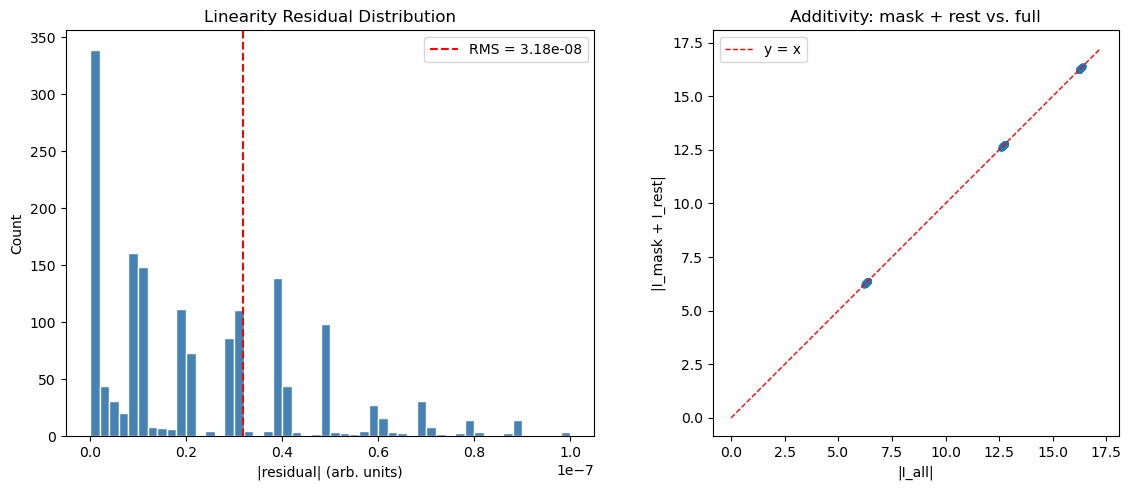

In [15]:
# Linearity check (real and imaginary parts)
d_real = (re_mask + re_rest) - re_all
d_imag = (im_mask + im_rest) - im_all
residual_mag = np.sqrt(d_real**2 + d_imag**2)
full_mag = np.sqrt(re_all**2 + im_all**2)

rms_residual = np.sqrt(np.mean(residual_mag**2))
rms_full = np.sqrt(np.mean(full_mag**2))

print(f"RMS |I_all|      : {rms_full:.6f}")
print(f"RMS residual     : {rms_residual:.2e}")
print(f"Relative error   : {rms_residual / rms_full:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of residual magnitudes
ax = axes[0]
ax.hist(residual_mag, bins=50, color="steelblue", edgecolor="white")
ax.axvline(rms_residual, color="red", ls="--", label=f"RMS = {rms_residual:.2e}")
ax.set_xlabel("|residual| (arb. units)")
ax.set_ylabel("Count")
ax.set_title("Linearity Residual Distribution")
ax.legend()

# Scatter: |I_mask + I_rest| vs |I_all|
ax = axes[1]
sum_mag = np.sqrt((re_mask + re_rest)**2 + (im_mask + im_rest)**2)
ax.scatter(full_mag, sum_mag, s=15, alpha=0.5)
lims = [0, max(full_mag.max(), sum_mag.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlabel("|I_all|")
ax.set_ylabel("|I_mask + I_rest|")
ax.set_title("Additivity: mask + rest vs. full")
ax.set_aspect("equal")
ax.legend()

fig.tight_layout()
plt.show()

## 9. Summary

This notebook demonstrated the MOSAIC workflow for **2D chemical short-range order** analysis
on a **PMN-PT** supercell:

1. **Structure loading** — a 2D slice from a 3D PMN-PT supercell (40 x 40 unit cells) with three B-site species: Nb (Z = 41), Ti (Z = 22), Mg (Z = 12)
2. **Coefficient-weighted scattering** — forward type-3 NUFFT using mean-centred atomic-number coefficients at average atomic positions
3. **Intensity visualisation** — total and diffuse scattering patterns with circular superstructure mask overlay
4. **Masked inverse transform** — circular mask isolates half-integer superstructure reflections associated with rocksalt-type CSRO
5. **Chemical ordering maps** — site-resolved scalar order parameter extracted via the Average-Position estimator
6. **Linearity verification** — $I_{\text{mask}} + I_{\text{rest}} = I_{\text{all}}$

Compared to the pure PMN case, the Ti substitution in PMN-PT partially disrupts the
rocksalt-type ordering, which can be seen as weaker contrast and smaller ordered domains
in the superstructure-filtered map.

In [16]:
# --- Cleanup: remove generated config files (optional) ---
# Uncomment below to remove demo output directories after inspection
# for d in ["output_demo_pmnpt_all", "output_demo_pmnpt_masked", "output_demo_pmnpt_rest"]:
#     p = EXAMPLE_DIR / d
#     if p.exists():
#         shutil.rmtree(p)
#         print(f"Removed {p}")